# Package and Data Importation

In [178]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import  matplotlib.pyplot as plt 
import pingouin as pg

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score,f1_score

In [3]:
df = pd.read_csv('Telco-Customer-Churn.csv')

# Data Overview (structural)

In [5]:
# check the dimensions of the dataset 
print('There are 21 columns and 7043 rows in this dataset.')
df.shape

There are 21 columns and 7043 rows in this dataset.


(7043, 21)

In [6]:
# preview dataset
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [7]:
print('As we can see below that there are no missing values but the Total charges colum seems to be the incorrect datatype') 
df.info()

As we can see below that there are no missing values but the Total charges colum seems to be the incorrect datatype
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   70

# Data Quality & Diagnostics

In [9]:
print('As you can see below, there are no duplicate values in this dataset')
# Check for duplicates by filtering for them 
df[df.duplicated()]

As you can see below, there are no duplicate values in this dataset


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [10]:
print("Blank spaces in TotalCharges:", (df['TotalCharges'] == ' ').sum())

Blank spaces in TotalCharges: 11


In [11]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Data Cleaning

In [13]:
print('Changing the data type for TotalCharges column')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Changing the data type for TotalCharges column


In [14]:
print('There were 11 mssing values found after implementing the coerce method.\nThe median was used to treat the missing values as this variable is skewed.')

total_charges_median = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(total_charges_median)

There were 11 mssing values found after implementing the coerce method.
The median was used to treat the missing values as this variable is skewed.


# Explatory Data Analysis(EDA)

## Statistical Summary

In [17]:
#numerical variables overview 
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [18]:
# categoric variable overview 
categoric_overview = df.describe(include='O')
categoric_overview

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


## Univariate Analysis 

### Numeric Columns 
In this section we will explore the distribution of the numeric columns as well as identify any anomolies 

In [21]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

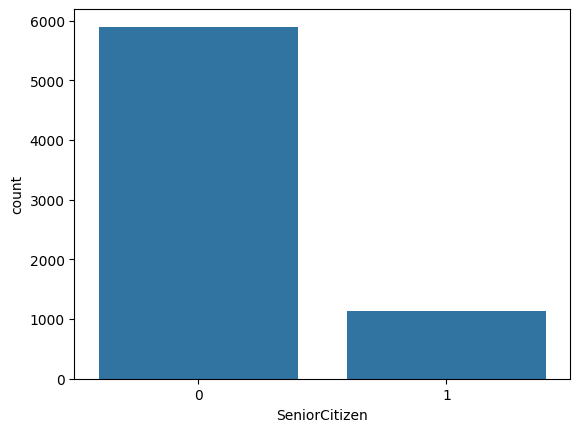

In [22]:
sns.countplot(data=df, x='SeniorCitizen');

Tenure 

<Axes: xlabel='tenure', ylabel='Count'>

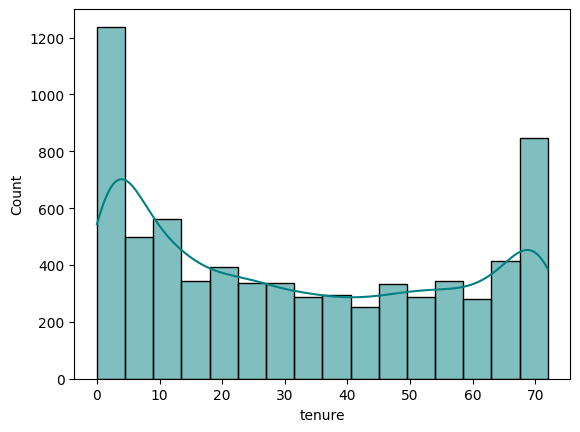

In [24]:
sns.histplot(data= df, x='tenure', kde=True, color='teal')

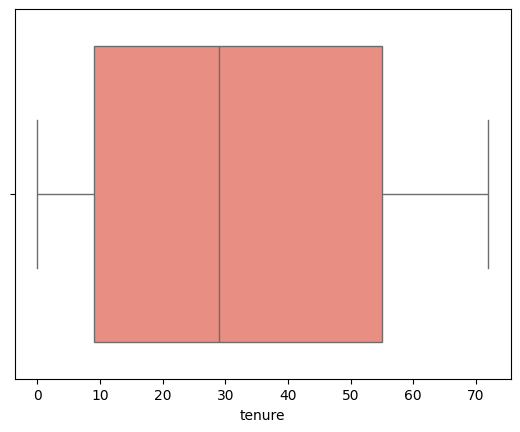

In [25]:
sns.boxplot(data=df, x='tenure', color='salmon');

MonthlyCharges

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

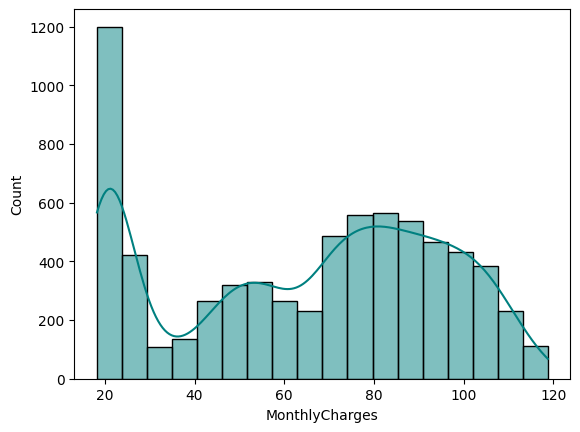

In [27]:
sns.histplot(data= df, x='MonthlyCharges', kde=True, color='teal')

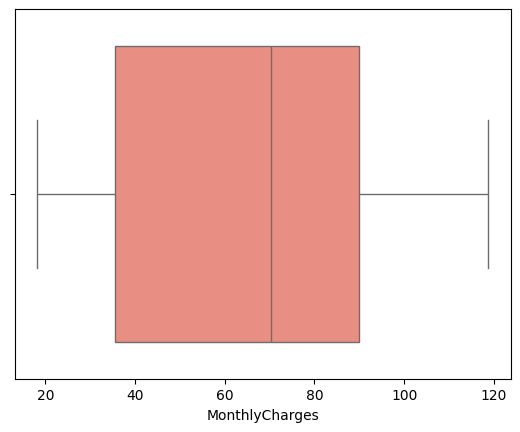

In [28]:
sns.boxplot(data=df, x='MonthlyCharges', color='salmon');

TotalCharges

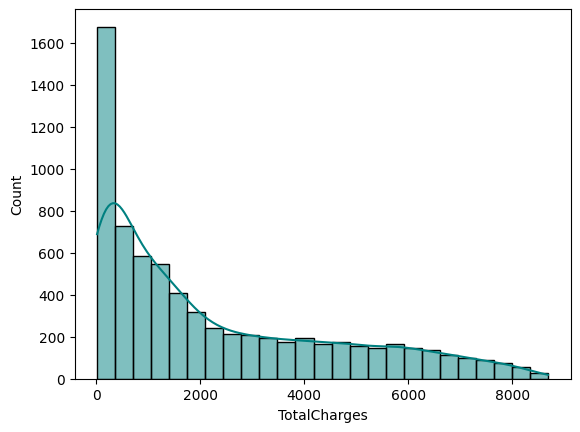

In [30]:
sns.histplot(data= df, x='TotalCharges', kde=True, color='teal');

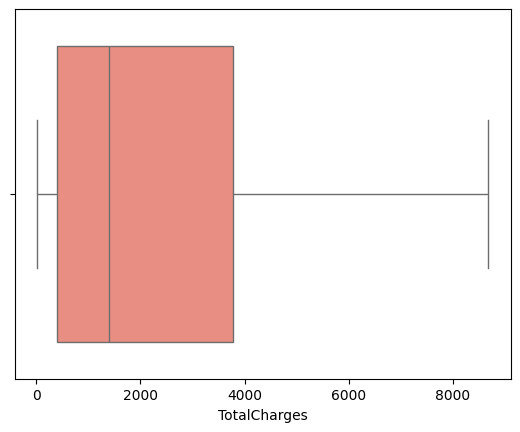

In [31]:
sns.boxplot(data=df, x='TotalCharges', color='salmon');

### Categorical columns 
In this section, we will explore the distribution of the categorical columns 

In [33]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

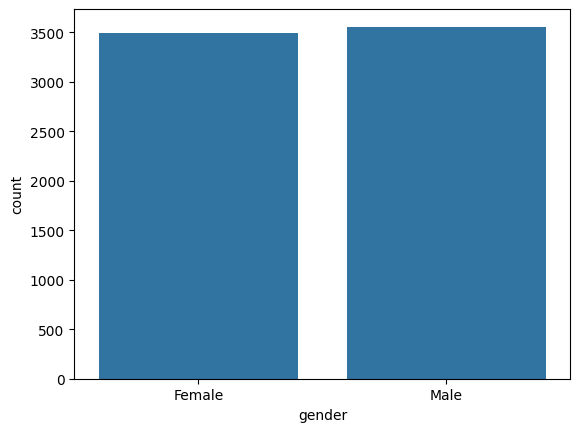

In [34]:
sns.countplot(data=df, x='gender');

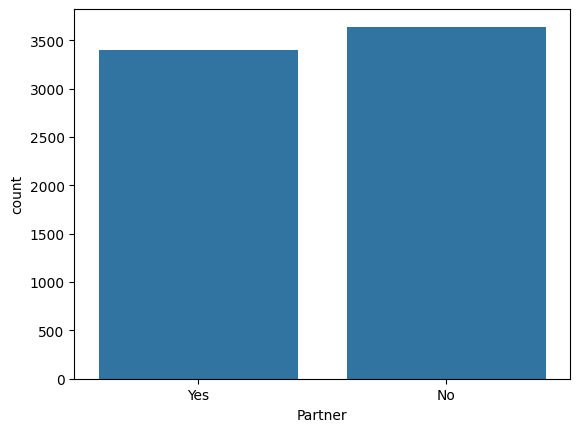

In [35]:
sns.countplot(data=df, x='Partner');

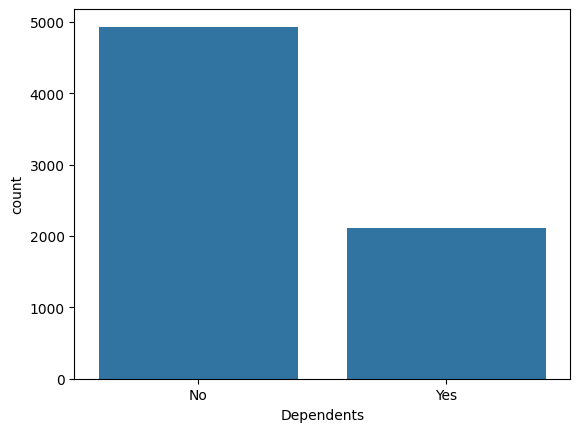

In [36]:
sns.countplot(data=df, x='Dependents');

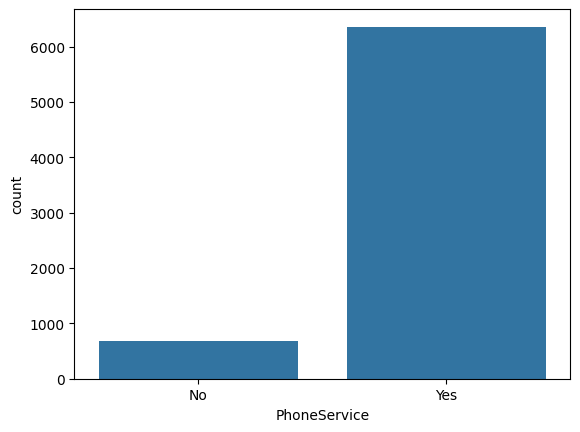

In [37]:
sns.countplot(data=df, x='PhoneService');
# ?

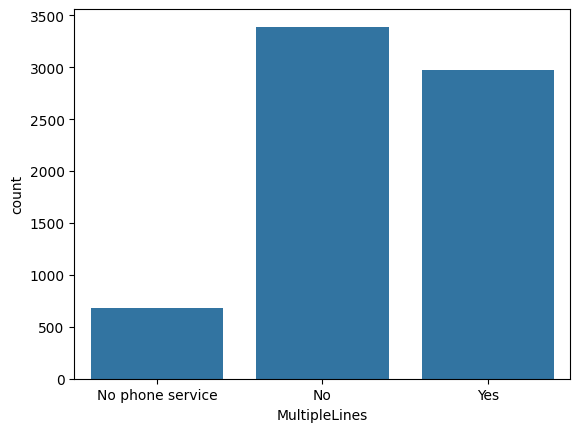

In [38]:
sns.countplot(data=df, x='MultipleLines');

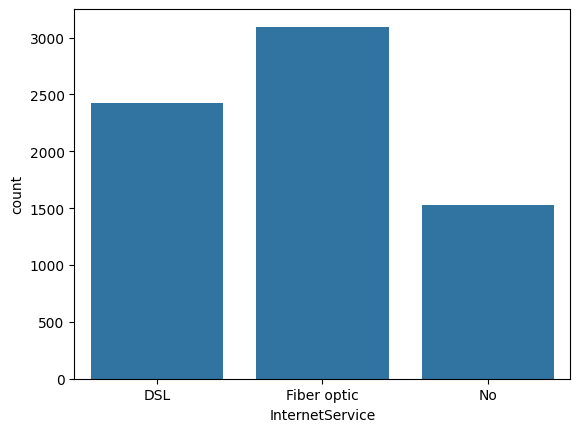

In [39]:
sns.countplot(data=df, x='InternetService');

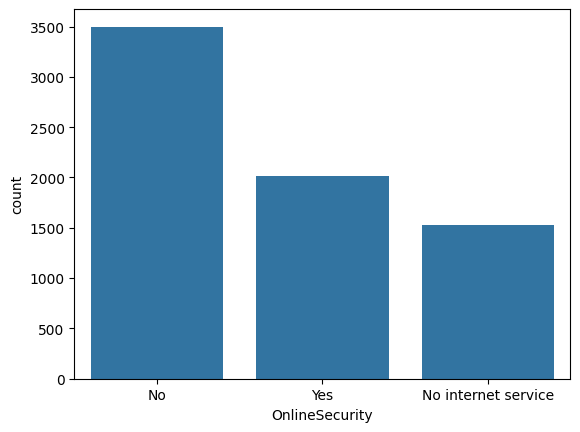

In [40]:
sns.countplot(data=df, x='OnlineSecurity');

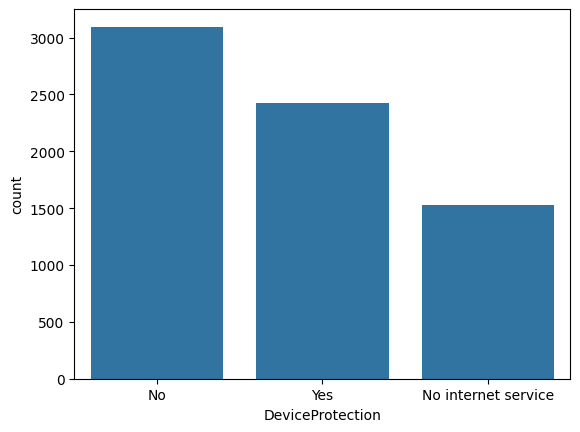

In [41]:
sns.countplot(data=df, x='DeviceProtection');

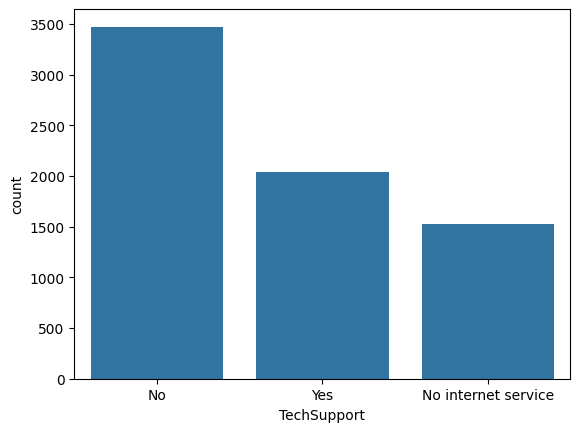

In [42]:
sns.countplot(data=df, x='TechSupport');

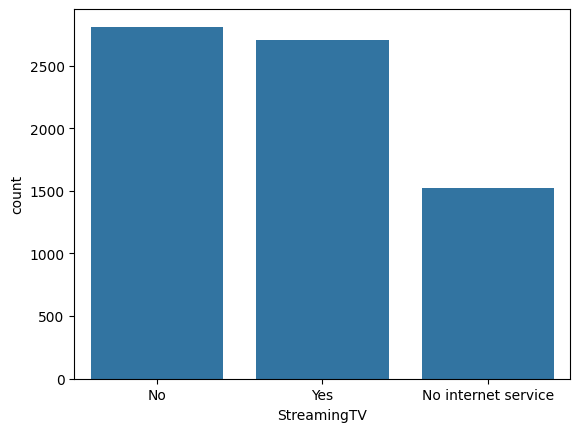

In [43]:
sns.countplot(data=df, x='StreamingTV');

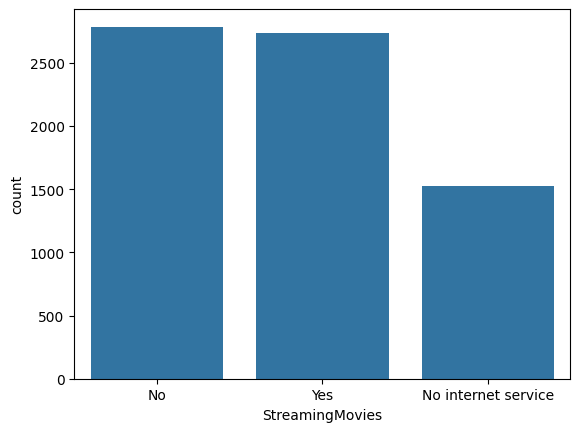

In [44]:
sns.countplot(data=df, x='StreamingMovies');

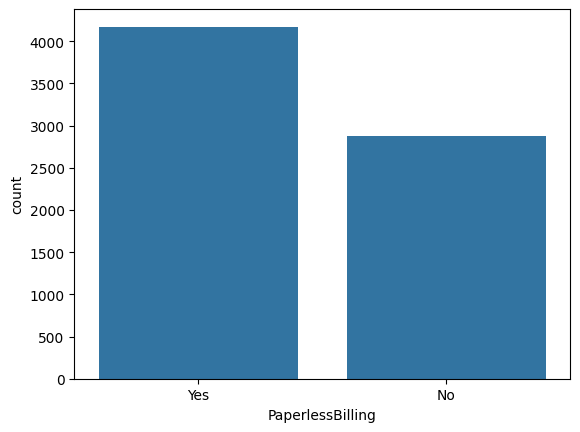

In [45]:
sns.countplot(data=df, x='PaperlessBilling');

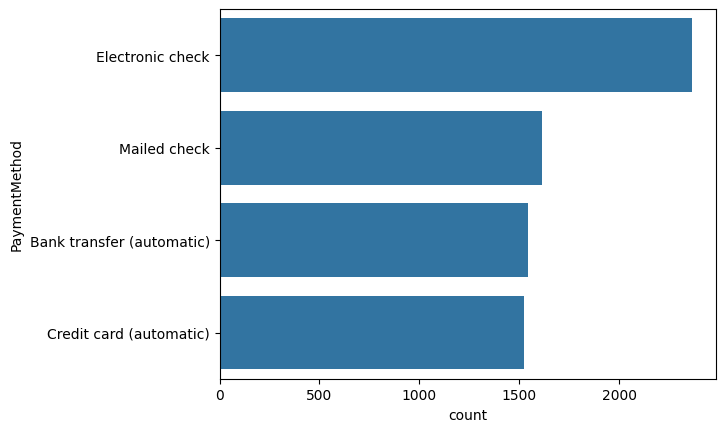

In [46]:
sns.countplot(data=df, y='PaymentMethod');

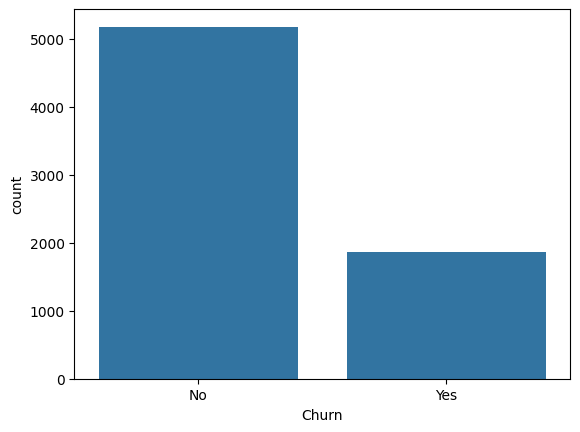

In [47]:
sns.countplot(data=df, x='Churn');

In [48]:
df.groupby('PhoneService')

In [49]:
cross_tab_table = pd.crosstab(columns = df['PhoneService'],index= df['Churn'])

In [50]:
expected, observed, stats = pg.chi2_independence(
    data=df, 
    x='PhoneService', 
    y='Churn', 
    correction=True)

In [51]:
expected

Churn,No,Yes
PhoneService,,
No,501.017748,180.982252
Yes,4672.982252,1688.017748


In [52]:
observed

Churn,No,Yes
PhoneService,,
No,511.5,170.5
Yes,4662.5,1698.5


In [53]:
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,0.915033,1.0,0.338783,0.011398,0.159606
1,cressie-read,0.666667,0.918472,1.0,0.337876,0.011420,0.160029
2,log-likelihood,0.000000,0.925475,1.0,0.336041,0.011463,0.160891
3,freeman-tukey,-0.500000,0.930839,1.0,0.334645,0.011496,0.161552
4,mod-log-likelihood,-1.000000,0.936298,1.0,0.333232,0.011530,0.162224
5,neyman,-2.000000,0.947515,1.0,0.330353,0.011599,0.163606


The chi square test reveals that the phoneService is independent of the churn and therefore can be dropped 

# Feature selection 

In [56]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [57]:
df.drop('customerID',axis=1,inplace=True)

# Data Processing for Modelling 

In [59]:
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [60]:
df['Churn'] = df['Churn'].map({'No':0,'Yes':1})

In [61]:
# there are 3 types of encoding :
# - Label encoding : 

In [62]:
encoded_df = pd.get_dummies(data = df ,drop_first=True,dtype='int')

In [63]:
encoded_df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,1,1,1,1,0,...,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,0,1,1,1,0,...,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,0,1,1,0,1,...,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,1,0,1,0,...,0,0,0,0,0,0,1,0,0,1


## Data splitting 

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
y = encoded_df['Churn']
X = encoded_df.drop('Churn',axis = 1)

In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25, stratify = y, random_state =42)

In [68]:
# XG boost , random forest, logistic regression, gradient boost 

# Model Building -(simple) No Hyparameter tuning 

## Building the Logistic Regression Model.. 

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score,f1_score

In [72]:
# Instantiating Lostistic regression
simple_logistic_regression_model = LogisticRegression(max_iter=10000)
# Training the Simple logistic regression model 
simple_logistic_regression_model.fit(X_train,y_train)
# Predict using the Simple logistic regression model 
y_pred = simple_logistic_regression_model.predict(X_test)
# Print Train accuracy 
print(f'Train Accuracy score:{simple_logistic_regression_model.score(X_train,y_train)}')
#Print Test accuracy 
print(f'Test Accuracy score:{simple_logistic_regression_model.score(X_test,y_test)}')

Train Accuracy score:0.807080651268459
Test Accuracy score:0.8080636002271436


## Building the Random Forest Model..

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
# Instantiating Random Forest 
simple_random_forest_classifier = RandomForestClassifier()
# Training the Simple Random Forest Model 
simple_random_forest_classifier.fit(X_train,y_train)
# Predict using the Simple Random Forest Model 
y_pred = simple_random_forest_classifier.predict(X_test)
# Print Train accuracy
print(f'Train Accuracy score:{simple_random_forest_classifier.score(X_train,y_train)}')
# Print Test accuracy
print(f'Test Accuracy score:{simple_random_forest_classifier.score(X_test,y_test)}')

Train Accuracy score:0.9979174555092768
Test Accuracy score:0.7887563884156729


## Building the Gradient Boosting Classifier..

In [77]:
from sklearn.ensemble import GradientBoostingClassifier

In [78]:
# Instantiating Gradient Boost Classifier 
simple_gbc = GradientBoostingClassifier()
# Training Gradient Boost CLassifier 
simple_gbc.fit(X_train,y_train)
# Predict using Gradient Boost Classifier 
y_pred = simple_gbc.predict(X_test)
# Print Train accuracy
print(f'Train Accuracy score:{simple_gbc.score(X_train,y_train)}')
# Print Test accuracy
print(f'Test Accuracy score:{simple_gbc.score(X_test,y_test)}')

Train Accuracy score:0.829420673987126
Test Accuracy score:0.7938671209540034


## Building the XGB Model ..

In [80]:
from xgboost import XGBClassifier

In [81]:
# Instantiating XGB Classifier 
simple_XGB = XGBClassifier()
# Training XGB model 
simple_XGB.fit(X_train,y_train)
# Predict XGB model
y_pred = simple_XGB.predict(X_test)
# Print Train accuracy
print(f'Train Accuracy score:{simple_XGB.score(X_train,y_train)}')
# Print Test accuracy
print(f'Test Accuracy score:{simple_XGB.score(X_test,y_test)}')

Train Accuracy score:0.9316546762589928
Test Accuracy score:0.7847813742191937


# Model Building with Hyparameter tuning 

## Logistic Regression with hyper parameter Tuning 

In [84]:
from sklearn.model_selection import GridSearchCV

In [85]:
# Instantiating Lostistic regression
logistic_regression_model_tuned= LogisticRegression(max_iter=10000)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10,15, 100]}
grid_search = GridSearchCV( logistic_regression_model_tuned , param_grid, cv=5)

grid_search.fit(X_train, y_train)
print("Test set score: {:.2f}".format(grid_search.score(X_test, y_test)))
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))
print("Best estimator:\n{}".format(grid_search.best_estimator_))

Test set score: 0.81
Best parameters: {'C': 10}
Best cross-validation score: 0.81
Best estimator:
LogisticRegression(C=10, max_iter=10000)


**Building Final model** 

In [87]:
# Instantiating Lostistic regression
log_reg_model_final= LogisticRegression(C=10,max_iter=10000)
# traininig the model
log_reg_model_final.fit(X,y)
# Train accuracy 
print(f'Train score:{log_reg_model_final.score(X_train,y_train)}')
y_pred_log_final = log_reg_model_final.predict(X_test)
print(f'Test score:{accuracy_score(y_test,y_pred_log_final)}')

Train score:0.8068913290420295
Test score:0.8080636002271436


## Random Forest Model with hyperparameter tuning 

In [89]:
#Instantiating random forest 
rf_model = RandomForestClassifier(max_depth=10, max_features=13, max_leaf_nodes=9)
# training the random forest model 
rf_model.fit(X_train,y_train)
# predicting with random forest 
rf_pred = rf_model.predict(X_test) 
print(f'Train score:{rf_model.score(X_train,y_train)}')
print(f'Test score:{accuracy_score(y_test,rf_pred)}')

Train score:0.794774706550549
Test score:0.7836456558773425


In [90]:
# Instantiating Lostistic regression
rf_model_tuned = RandomForestClassifier()

param_grid = {'max_depth': [10, 14, 20, 16, 11,15],
              'max_leaf_nodes': [4, 6, 7, 9, 3,2], # 
              'max_features': [10, 17, 13, 15, 14,18]} # numbers can be any positive number.
                                                       #The length of the number list must match the number of columns  
grid_search = GridSearchCV( rf_model_tuned , param_grid, cv=5)

grid_search.fit(X_train, y_train)
print("Test set score: {:.2f}".format(grid_search.score(X_test, y_test)))
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))
print("Best estimator:\n{}".format(grid_search.best_estimator_))

Test set score: 0.78
Best parameters: {'max_depth': 14, 'max_features': 10, 'max_leaf_nodes': 9}
Best cross-validation score: 0.80
Best estimator:
RandomForestClassifier(max_depth=14, max_features=10, max_leaf_nodes=9)


In [91]:
# Instantiating Lostistic regression
rf_model_tuned_final= RandomForestClassifier(max_depth=16, max_features=14, max_leaf_nodes=9)
# traininig the model
rf_model_tuned_final.fit(X_train,y_train)
# Train accuracy 
print(f'Train score:{rf_model_tuned_final.score(X_train,y_train)}')
y_pred_rf_final = rf_model_tuned_final.predict(X_test)
print(f'Test score:{accuracy_score(y_test,y_pred_rf_final)}')


Train score:0.794774706550549
Test score:0.7825099375354913


## Gradient Boost with hyperparameter Tuning 

In [93]:
# Instantiating gradient boost
gbc_model_tuned = GradientBoostingClassifier()

param_grid = {'max_depth': [10, 14, 20, 16, 11,15],
              'max_features': [10, 17, 13, 15, 14,18],
              'max_leaf_nodes': [4, 6, 7, 9, 3,2]}
grid_search = GridSearchCV( gbc_model_tuned , param_grid, cv=5)


In [94]:
grid_search.fit(X_train, y_train)
print("Test set score: {:.2f}".format(grid_search.score(X_test, y_test)))
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))
print("Best estimator:\n{}".format(grid_search.best_estimator_))

Test set score: 0.80
Best parameters: {'max_depth': 16, 'max_features': 10, 'max_leaf_nodes': 3}
Best cross-validation score: 0.81
Best estimator:
GradientBoostingClassifier(max_depth=16, max_features=10, max_leaf_nodes=3)


In [95]:
# Instantiating gradient boost 
gbc_model_tuned_final= GradientBoostingClassifier(max_depth=15, max_features=14,max_leaf_nodes = 3)
# traininig the model
gbc_model_tuned_final.fit(X_train,y_train)
# Train accuracy 
print(f'Train score:{gbc_model_tuned_final.score(X_train,y_train)}')
y_pred_gbc_final = rf_model_tuned_final.predict(X_test)
print(f'Test score:{accuracy_score(y_test,y_pred_gbc_final)}')

Train score:0.8127603180613404
Test score:0.7825099375354913


## XGB 

In [97]:
xgb_model_tuned  = XGBClassifier(max_depth=10, max_leaves=13,learning_rate = 0.7 )
# training the xg boost model 
xgb_model_tuned.fit(X_train,y_train)
# predicting with XG boost 
xgb_model_tuned_pred = xgb_model_tuned.predict(X_test) 
print(f'Train score:{xgb_model_tuned.score(X_train,y_train)}')
print(f'Test score:{accuracy_score(y_test,xgb_model_tuned_pred)}')

Train score:0.9115865202574782
Test score:0.7677455990914254


In [98]:
# Instantiating xg boost
xgb_model_tuned = XGBClassifier()

param_grid = {'max_depth': [10, 14, 20, 16, 11,15],
              'max_leaves': [4, 6, 7, 9, 3,2],
              'learning_rate': [0.1, 0.5, 0.001, 0.01, 0.0001,0.2]}
grid_search = GridSearchCV( xgb_model_tuned , param_grid, cv=5)

grid_search.fit(X_train, y_train)
print("Test set score: {:.2f}".format(grid_search.score(X_test, y_test)))
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))
print("Best estimator:\n{}".format(grid_search.best_estimator_))

Test set score: 0.80
Best parameters: {'learning_rate': 0.2, 'max_depth': 10, 'max_leaves': 3}
Best cross-validation score: 0.81
Best estimator:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=3,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)


In [99]:
# Instantiating xg boost 
xgb_model_tuned_final= XGBClassifier(max_depth=10, max_leaves=3,learning_rate = 0.2)
# traininig the model
xgb_model_tuned_final.fit(X_train,y_train)
# Train accuracy 
print(f'Train score:{xgb_model_tuned_final.score(X_train,y_train)}')
y_pred_xgb_final = xgb_model_tuned_final.predict(X_test)
print(f'Test score:{accuracy_score(y_test,y_pred_xgb_final)}')

Train score:0.8152215070049224
Test score:0.7989778534923339


# Evaluation 

### Train Accuracy 

In [195]:
# train_accuracies
lg_train_accuracy = log_reg_model_final.score(X_train,y_train)
rf_train_accuracy = rf_model_tuned_final.score(X_train,y_train)
gbc_train_accuracy = gbc_model_tuned_final.score(X_train,y_train)
xgb_train_accuracy = xgb_model_tuned_final.score(X_train,y_train)

### Test Score

In [192]:
lg_test_accuracy = accuracy_score(y_test,y_pred_log_final)
rf_test_accuracy = accuracy_score(y_test,y_pred_rf_final)
gbc_test_accuracy = accuracy_score(y_test,y_pred_gbc_final)
gbc_test_accuracy = accuracy_score(y_test,y_pred_xgb_final)

In [190]:
gbc_test_accuracy

0.7825099375354913